# Explore Loss Functions

In this section, the model will be trained using the following loss functions:

1. MSE
2. MAE
3. Huber
4. Adaptive

The $R^2$ score will also be computed for each loss function.

## Libraries

In [11]:
# Prevent OpenMP runtime conflict between libraries like PyTorch, TensorFlow, and NumPy on Windows
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import os
sys.path.append(os.path.abspath(".."))

import importlib
import src.training_utils as tu
importlib.reload(tu)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

## Load Data
Load the data prepared in `01_data_preparation.ipynb`.

In [3]:
data = torch.load('../saved_values/data.pt', weights_only=False)

x_train = data["x_train"]
y_train = data["y_train"]

x_valid = data["x_valid"]
y_valid = data["y_valid"]

x_test = data["x_test"]
y_test = data["y_test"]

## Convert to Tensors

Since the data is currently in NumPy array format, I will convert it to PyTorch tensors.

In [4]:
x_train = torch.FloatTensor(x_train)
y_train = torch.FloatTensor(y_train)

x_valid = torch.FloatTensor(x_valid)
y_valid = torch.FloatTensor(y_valid)

x_test = torch.FloatTensor(x_test)
y_test = torch.FloatTensor(y_test)

## Data Loader

Create data loaders for the training, validation, and test sets.

In [5]:
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

valid_dataset = TensorDataset(x_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=256)

test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256)

## Define the Model Architecture

In [6]:
model = tu.Model(in_features=20, h1=64, h2=32, out_features=1)

## Optimizer
The optimizer used in this notebook is Adam.

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Loss functions
In this section I will train the model with these loss functions:
1. MSE
2. MAE
3. Huber
4. Adaptive

### 1. Mean Squared Error
$$
\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

In [8]:
loss_fn = nn.MSELoss()

In [9]:
trainer = tu.Trainer(model=model, optimizer=optimizer, loss_fn=loss_fn)

history = trainer.fit(train_loader, valid_loader, epochs=300, log_every=10)

Output()

          Epoch 1/300           
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.4889 │     0.3121 │
│ R²     │ 0.5108 │     0.6977 │
└────────┴────────┴────────────┘

          Epoch 10/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2309 │     0.2819 │
│ R²     │ 0.7691 │     0.7339 │
└────────┴────────┴────────────┘

          Epoch 20/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2125 │     0.2538 │
│ R²     │ 0.7876 │     0.7614 │
└────────┴────────┴────────────┘

          Epoch 30/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2005 │     0.2467 │
│ R²     │ 0.7996 │     0.7684 │
└────────┴────────┴────────────┘

...

         Epoch 260/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1381 │     0.2466 │
│ R²     │ 0.8619 │     0.7670 │
└────────┴────────┴────────────┘

         Epoch 270/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1373 │     0.2372 │
│ R²     │ 0.8626 │     0.7725 │
└────────┴────────┴────────────┘

         Epoch 280/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1362 │     0.2556 │
│ R²     │ 0.8639 │     0.7606 │
└────────┴────────┴────────────┘

         Epoch 290/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1349 │     0.2408 │
│ R²     │ 0.8652 │     0.7707 │
└────────┴────────┴────────────┘

         Epoch 300/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1350 │     0.2443 │
│ R²     │ 0.8650 │     0.7675 │
└────────┴────────┴────────────┘

#### Plot the Results

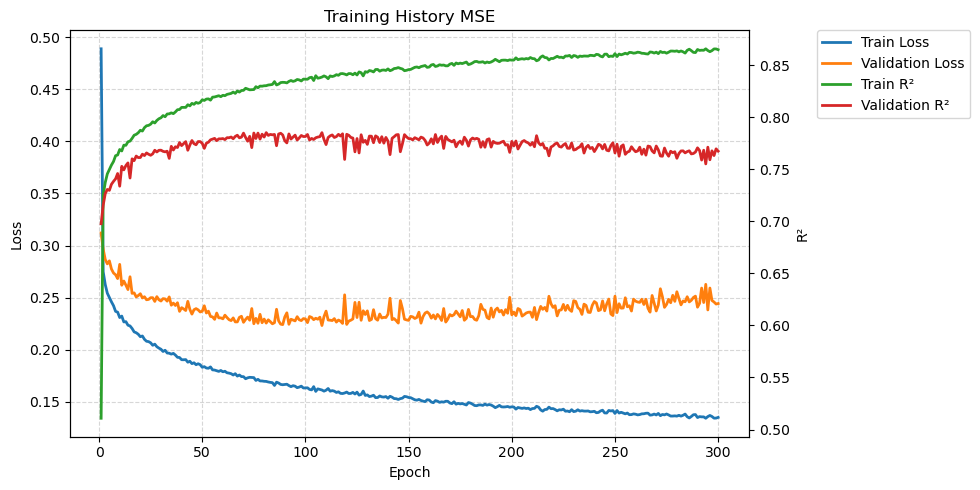

In [12]:
tu.plot_training_history(history, "MSE")